In [2]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score
!pip install catboost
#!pip install xgboost
#from xgboost import XGBClassifier

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.2 MB/s eta 0:00:00


### Task 1

In [3]:
df = pd.read_csv("/content/credit_card_payment_delay(final) (1).csv")

In [4]:
df.head()

,datekey,dim_card_key,ss_number,account_number,account_status,card_number,card_status,primary_card,card_limit,card_product,...,penalty_charges,annual_fee,currentoverduedays,next_billing_date,gender,age,payment_delay,CIFKey,year,salary
0,20220831,1000,320-51-3430,1002180,ACTIVE,7405536091847318,ACTIVE,0,50000,VISA Signature,...,0.0,5000,1,9/30/2022,F,72,yes,C2872,1970,82612.0
1,20220930,1000,320-51-3430,1002180,ACTIVE,7405536091847318,ACTIVE,0,50000,VISA Signature,...,0.0,0,0,10/31/2022,F,72,no,C2872,1970,88222.0
2,20221031,1000,320-51-3430,1002180,ACTIVE,7405536091847318,ACTIVE,0,50000,VISA Signature,...,0.0,0,1,11/30/2022,F,72,no,C2872,1970,92064.0
3,20221130,1000,320-51-3430,1002180,ACTIVE,7405536091847318,ACTIVE,0,50000,VISA Signature,...,0.0,5000,2,12/31/2022,F,72,no,C2872,1970,97931.0
4,20221231,1000,320-51-3430,1002180,ACTIVE,7405536091847318,ACTIVE,0,50000,VISA Signature,...,0.0,5000,1,1/31/2023,F,72,no,C2872,1970,104011.0


In [5]:
df.shape
#Contains 156180 rows with 30 features. Here each row represent monthly level records of each account number .

(156180, 30)

In [6]:
#The below columns have removed as they are non informative and sensitive features.
df = df.drop(columns=['dim_card_key', 'ss_number','card_number' ,'card_created_date','canvass_employee_id','next_billing_date','CIFKey','year'])


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156180 entries, 0 to 156179
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   datekey               156180 non-null  int64  
 1   account_number        156180 non-null  int64  
 2   account_status        156180 non-null  object 
 3   card_status           156180 non-null  object 
 4   primary_card          156180 non-null  int64  
 5   card_limit            156180 non-null  int64  
 6   card_product          156180 non-null  object 
 7   employee_designation  156180 non-null  object 
 8   customer_type         156180 non-null  object 
 9   build_outstanding     156180 non-null  float64
 10  unamortized_amt       156180 non-null  int64  
 11  total_outstanding     156180 non-null  float64
 12  spend_amount          156180 non-null  float64
 13  payment               156180 non-null  float64
 14  interest              156180 non-null  float64
 15  



* The dataset used in here was provided by X bank and consistes of historical credit card records extracted from the bank's internal credit card management
*  The dataset contains 156180 monthly level records , where each record represents a credit card account's activity for specific billing cycle.
*   The row dataset contains account number , card status , ard product , card limit , account status , age , gender , customer type , salary , spending amount , total outstanding balance , penalty charges , interest , annual fee, number of overdue days , payment amounts and payment delay indicator.









### Task 2

In [8]:
df.isnull().sum()

,0
datekey,0
account_number,0
account_status,0
card_status,0
primary_card,0
card_limit,0
card_product,0
employee_designation,0
customer_type,0
build_outstanding,0


In [9]:
df = df.dropna() #no null values present .





*   Transforming the data set was tranfrome into an account level feature engineered dataset for predicitive modeling.





In [10]:
counts = df['account_number'].value_counts()
valid_accounts = counts[counts > 35].index
df_filtered = df[df['account_number'].isin(valid_accounts)]

In [11]:
df = df.sort_values(['account_number']).reset_index(drop=True)

In [12]:
df = df.sort_values(['account_number', 'datekey'])

In [13]:

final_rows = []

for acc, group in df.groupby('account_number'):

    # sort by time so latest is last
    group = group.sort_values('datekey')

    group = group.tail(36)

    # Target = latest payment_delay
    y = group.iloc[-1]['payment_delay']

    row = {
        'account_number': acc,
        'payment_delay_target': y
    }

    # Create 35 lag features from previous records
    history = group.iloc[:-1]

    for i in range(35):
        if i < len(history):

            row[f'payment_delay{35-i}'] = history.iloc[-(i+1)]['payment_delay']
        else:
            row[f'payment_delay{35-i}'] = np.nan


    last_row = group.iloc[-1]

    for col in df.columns:
        if col not in ['account_number', 'payment_delay']:
            row[col] = last_row[col]

    final_rows.append(row)

In [14]:
final_df = pd.DataFrame(final_rows)
final_df.head()


,account_number,payment_delay_target,payment_delay35,payment_delay34,payment_delay33,payment_delay32,payment_delay31,payment_delay30,payment_delay29,payment_delay28,...,total_outstanding,spend_amount,payment,interest,penalty_charges,annual_fee,currentoverduedays,gender,age,salary
0,11015,no,no,no,no,yes,no,no,no,no,...,1111.81,2386.48,1354.34,8.93,0.0,0,1,F,67,2196491.0
1,12838,yes,no,no,no,no,no,no,no,no,...,30692.15,13632.05,17993.42,176.27,0.0,0,5,M,71,38937801.0
2,19176,yes,no,yes,yes,no,yes,yes,yes,no,...,28188.20,14173.16,7842.25,257.03,0.0,0,0,M,36,33538647.0
3,32990,no,no,no,no,no,no,yes,no,no,...,4313.21,7635.32,3115.52,6.36,0.0,5000,0,F,46,751388.0
4,34713,no,no,no,yes,no,no,yes,no,no,...,11208.93,8048.33,2317.01,51.52,0.0,0,2,F,66,7838051.0


In [15]:
final_df.shape

(5464, 57)



*   Final Dataset contains 5464 unique account numbers with 57 features.




In [16]:
pd.options.display.float_format = '{:.0f}'.format

Description of variables

1.   Account number : Variable type is Integer , Unique indentifer of each account.
2.  Payement_delay_target : Categorical(Yes/No) , Target variable indicating wheather the customer delay the oayment or not.
3. Payment_delay1 -payment_delay35 : Categorical (Yes/No) Historical payment delay accross past billing cycles.
4. account_status : Categorical(Active/Closed)
5. card_status : Categorical(Active/Closed)
6. Card_Limit : Quantitative, Maximum card limit assigned to a customer.
7. Card_Product : Categorical, Type or category of the credit card. (Visa_Signature , PLATINUM , AMEX Blue)
8. Employee_Designation : Categorical (Engineer , Teacher , Manager , Assistant and Sales execative)
9. Customer_type : Categorical , Type of the customer (Revolver or Transactor)
10. Build_outsatnding : Quantitative , Outsanding amount carried forward.
11. unamortized_amt : Quantitative , Remaining amount yet to be paid over time .
12. total_outsanding : Quantitative , Total outsanding balance .
13. Spend_amount : Quantitative variable , Total spending by customer
14. payment : Quantitative , Amount paid by customer.
15. Interest : Quantitative variable ,  Interest charged by the customer .
16. penalty_charges : Quantiative , Charges due to late paymenets.
17. annual_fee : Annual Fee of the card , this is a quantitative variable.
18. currentoverduedays: Discrete quantitative variable . Number of currev=net overdue days
19. gender : Categorical variable . Gender of the cutomer.
20. age : Quantitative , Age of the customer.
21. Salary : Quantitative variable , Income of the customer.

In [17]:
df.duplicated().sum()
#No duplicates present as the account numbers are unique .

np.int64(0)

In [19]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5464 entries, 0 to 5463
Data columns (total 57 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   account_number        5464 non-null   int64  
 1   payment_delay_target  5464 non-null   object 
 2   payment_delay35       5362 non-null   object 
 3   payment_delay34       5270 non-null   object 
 4   payment_delay33       5180 non-null   object 
 5   payment_delay32       5083 non-null   object 
 6   payment_delay31       4977 non-null   object 
 7   payment_delay30       4891 non-null   object 
 8   payment_delay29       4798 non-null   object 
 9   payment_delay28       4684 non-null   object 
 10  payment_delay27       4600 non-null   object 
 11  payment_delay26       4505 non-null   object 
 12  payment_delay25       4405 non-null   object 
 13  payment_delay24       4306 non-null   object 
 14  payment_delay23       4196 non-null   object 
 15  payment_delay22      

In [20]:
final_df['primary_card'] = final_df['primary_card'].astype('object')


In [39]:
final_df.drop(columns=['account_number', 'datekey'], inplace=True)

KeyError: "['account_number', 'datekey'] not found in axis"

In [41]:
final_df.drop(columns=['unamortized_amt'], inplace=True)

Payement delay history analysis

In [25]:
delay_cols = [col for col in final_df.columns if col.startswith('payment_delay') and col != 'payment_delay_target']


final_df[delay_cols] = final_df[delay_cols].replace({'yes': 1, 'no': 0})
#final_df[delay_cols]

/tmp/ipykernel_4158/2386207973.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  final_df[delay_cols] = final_df[delay_cols].replace({'yes': 1, 'no': 0})


In [26]:
delay_cols = [col for col in final_df.columns
              if col.startswith('payment_delay') and col != 'payment_delay_target']

In [27]:
# Convert to object (string) type
final_df[delay_cols] = final_df[delay_cols].astype(object)

In [28]:
# Total delayed months
final_df['total_delayed_months'] = final_df[delay_cols].sum(axis=1)



In [30]:
# Get all delay columns
delay_cols = [col for col in final_df.columns if col.startswith('payment_delay') and col != 'payment_delay_target']

# Convert yes/no → 1/0
final_df[delay_cols] = final_df[delay_cols].replace({
    'yes': 1, 'no': 0,
    'Yes': 1, 'No': 0
})

# Convert target also
final_df['payment_delay_target'] = final_df['payment_delay_target'].replace({
    'yes': 1, 'no': 0,
    'Yes': 1, 'No': 0
})

# Ensure numeric type
final_df[delay_cols] = final_df[delay_cols].astype(object)
final_df['payment_delay_target'] = final_df['payment_delay_target'].astype(object)

/tmp/ipykernel_4158/2984341864.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  final_df[delay_cols] = final_df[delay_cols].replace({
/tmp/ipykernel_4158/2984341864.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  final_df['payment_delay_target'] = final_df['payment_delay_target'].replace({


In [31]:
final_df['total_past_delays'] = final_df[delay_cols].sum(axis=1)

In [32]:
final_df['currentoverduedays'] = final_df['currentoverduedays'].astype(object)
final_df['annual_fee'] = final_df['annual_fee'].astype(object)

In [33]:
num_cols = final_df.select_dtypes(include=['int64', 'float64']).columns
num_df = final_df[num_cols]

In [34]:
cat_cols = final_df.select_dtypes(include=['object']).columns
cat_df = final_df[cat_cols]

### Task 3

In [35]:
final_df['total_delayed_months'].describe()

,total_delayed_months
count,5464
unique,25
top,3
freq,529


In [42]:
final_df.describe()

,card_limit,build_outstanding,total_outstanding,spend_amount,payment,interest,penalty_charges,age,salary
count,5464,5464,5464,5464,5464,5464,5464,5464,5464
mean,333904,4847,16189,9245,8949,90,24,49,121665948808
std,262375,4165,11771,4916,7642,84,66,18,4932820522444
min,50000,0,0,671,0,0,0,18,66652
25%,100000,1857,7396,5463,3547,30,0,33,962286
50%,250000,3646,13498,8747,6772,64,0,49,4877819
75%,500000,6630,22255,12056,12096,126,0,64,39058828
max,750000,33788,120383,41295,61870,735,300,80,352843405538284




*   Except for unamortized_amt , all the other variables contains outliers .
*   Age is normally distributed with few outliers.
*   Except age and unamortized_amt , the other variables are right skewed.





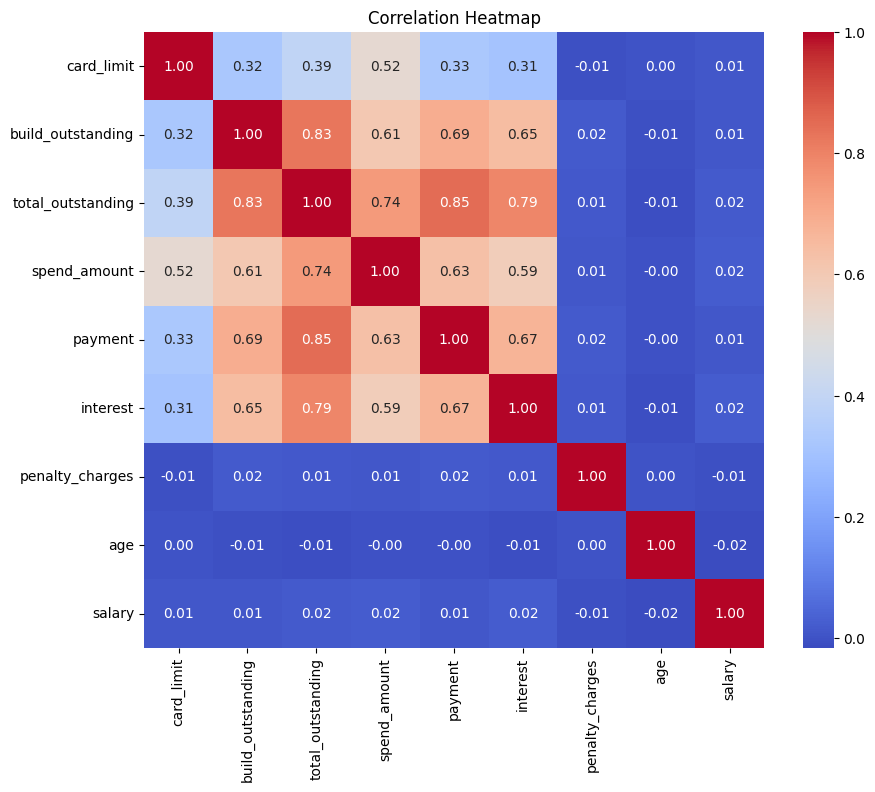

In [43]:
#Cheking the multicollinearity
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numerical columns (or your X variables)
corr = final_df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

The is a correlation between total_outsanding and buildoutstanding.
A correlation between total_outsanding and payement and interest too.


*   Removing the total outsnading column is the best option




In [45]:
final_df.drop(columns=['total_outstanding'], inplace=True)

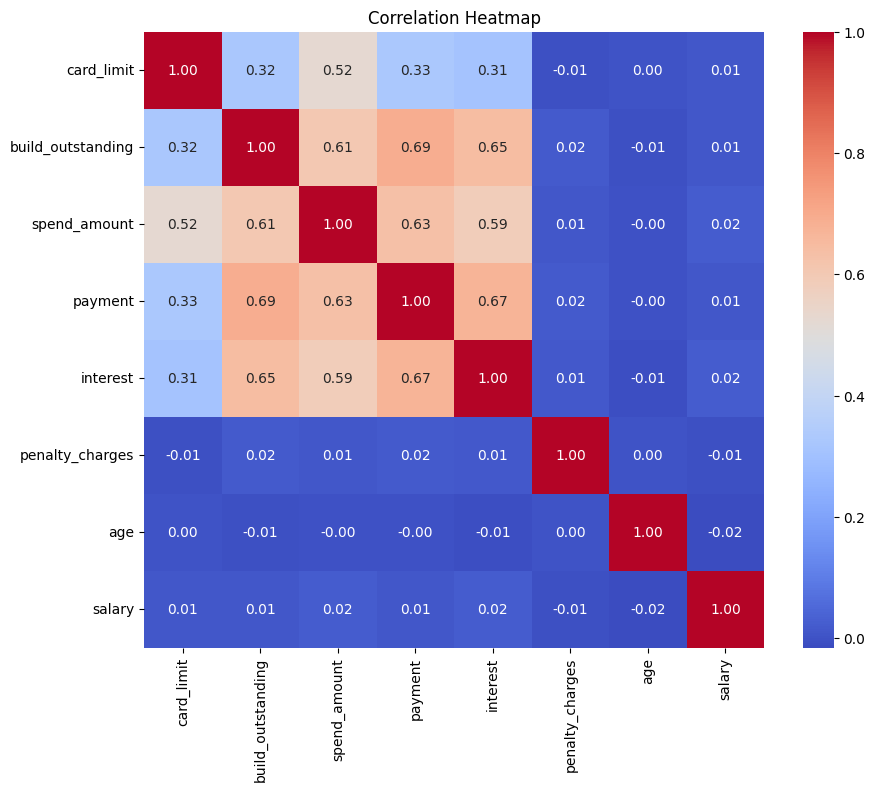

In [46]:
corr = final_df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [50]:
final_df['payment_delay_target'].value_counts()
#There is a higher class imbalance within the target variable.


,count
payment_delay_target,
0,4133
1,1331


In [51]:
df = final_df.copy()

df.shape

(5464, 55)

Feature selection using catboost


*   Only 11 features selected based on Recall for minority class and AUC value .
*   This is done  using backward elimination of features using the catboost model.



In [52]:
from sklearn.model_selection import train_test_split

In [53]:
X = df.drop(columns=['payment_delay_target'])
y = df['payment_delay_target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [54]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

In [55]:
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
from sklearn.preprocessing import LabelEncoder

N_FEATURES = 11

if y.dtype == 'object' or str(y.dtype) == 'category':
    y = LabelEncoder().fit_transform(y)


cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
X_temp = X.copy()

for col in cat_cols:
    X_temp[col] = X_temp[col].astype(str)

cat_features = [X_temp.columns.get_loc(c) for c in cat_cols]

base_model = CatBoostClassifier(verbose=0, random_seed=42)
base_model.fit(X_temp, y, cat_features=cat_features)

importances = base_model.get_feature_importance()

feature_ranking = sorted(
    zip(X.columns, importances),
    key=lambda x: x[1],
    reverse=True
)


selected_features = [f[0] for f in feature_ranking[:N_FEATURES]]
print("Selected Features:", selected_features)


X_sel = X[selected_features].copy()

cat_cols = X_sel.select_dtypes(include=['object', 'category']).columns.tolist()
for col in cat_cols:
    X_sel[col] = X_sel[col].astype(str)

cat_features = [X_sel.columns.get_loc(c) for c in cat_cols]

# -----------------------------
# Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_sel, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -----------------------------
# Train model
# -----------------------------
model = CatBoostClassifier(verbose=0, random_seed=42)
model.fit(X_train, y_train, cat_features=cat_features)

# -----------------------------
# Predictions
# -----------------------------
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# -----------------------------
# Metrics
# -----------------------------
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

precision = precision_score(y_test, y_pred, average=None, zero_division=0)
recall = recall_score(y_test, y_pred, average=None, zero_division=0)
f1 = f1_score(y_test, y_pred, average=None, zero_division=0)

# -----------------------------
# Output
# -----------------------------
print("===== Model Performance =====")
print("Accuracy :", accuracy)
print("AUC ROC  :", auc)

print("\n--- Class-wise Metrics ---")
print(f"Precision Class 0: {precision[0]:.4f}")
print(f"Precision Class 1: {precision[1]:.4f}")

print(f"Recall Class 0   : {recall[0]:.4f}")
print(f"Recall Class 1   : {recall[1]:.4f}")

print(f"F1-score Class 0  : {f1[0]:.4f}")
print(f"F1-score Class 1  : {f1[1]:.4f}")



Selected Features: ['build_outstanding', 'spend_amount', 'interest', 'payment', 'currentoverduedays', 'salary', 'age', 'total_delayed_months', 'total_past_delays', 'payment_delay22', 'payment_delay34']

===== Model Performance =====
Accuracy : 0.8353156450137237
AUC ROC  : 0.8563700666418161

--- Class-wise Metrics ---
Precision Class 0: 0.8467
Precision Class 1: 0.7688
Recall Class 0   : 0.9553
Recall Class 1   : 0.4624
F1-score Class 0  : 0.8977
F1-score Class 1  : 0.5775


In [56]:
print("\nFinal Selected Features List:")
print(selected_features)


Final Selected Features List:
['build_outstanding', 'spend_amount', 'interest', 'payment', 'currentoverduedays', 'salary', 'age', 'total_delayed_months', 'total_past_delays', 'payment_delay22', 'payment_delay34']


### Task 5

Prepraing data for modeling

In [59]:
X = df.drop(columns=['payment_delay_target'])
y = df['payment_delay_target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [60]:
y_train = y_train.astype(int)
y_test = y_test.astype(int)


In [62]:
X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]

Handling categorical variables (Only for seleted features)

In [63]:
cat_cols_selected = X_train_sel.select_dtypes(include=['object']).columns.tolist()

X_train_enc = pd.get_dummies(X_train_sel, columns=cat_cols_selected, drop_first=True)
X_test_enc = pd.get_dummies(X_test_sel, columns=cat_cols_selected, drop_first=True)

# Align columns
X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join='left', axis=1, fill_value=0)

Scaling (only numerical variables)
*   Due to skewness the rhobust scaling is use

In [65]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train_enc)
X_test_scaled = scaler.transform(X_test_enc)

Handling class imbalance


*   Using of class weights is better than using other techniques beacuse it adjust the learning process without altering the original data distribution.



In [67]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)

class_weights = dict(zip(classes, weights))

Use of XGBoost model for predictions

In [68]:
from xgboost import XGBClassifier


xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_scaled, y_train)


In [69]:
from sklearn.metrics import roc_auc_score, f1_score, classification_report
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

In [72]:

auc = roc_auc_score(y_test, y_prob_xgb )
f1 = f1_score(y_test, y_pred_xgb )

print("XGBoost AUC:", round(auc, 4))
print("XGBoost F1-score:", round(f1, 4))

#  10. Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost AUC: 0.8351
XGBoost F1-score: 0.5618

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.93      0.89       827
           1       0.70      0.47      0.56       266

    accuracy                           0.82      1093
   macro avg       0.77      0.70      0.72      1093
weighted avg       0.81      0.82      0.81      1093





*   Overall accuracy is 82% which implies that 82% of the predictions are correct model. Since the dataset is imbalanced , accuracy alone cannot use to measure the performance.
*  AUC value is 83.51% which indicates that there is a good ability to distinguch between 2 classes.
*   F1 score for the posstive class is 0.5618 which which implifies the moderate balance between precision and recall for the minority class.




